In [1]:
import pandas as pd
import numpy as np

REF_CSV = "../data/res/calibration/reference.csv" 

df = pd.read_csv(REF_CSV)

z = df["z_evidence"].dropna().to_numpy(dtype=float)

# ===== helper =====
def mad(x):
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))

def trimmed_mean(x, p=0.1):
    x = np.sort(x)
    n = len(x)
    k = int(n * p)
    return np.mean(x[k:n-k])

# ===== stats =====
med = np.median(z)
mean = np.mean(z)
std = np.std(z)
mad_val = mad(z)

print("=== reference stats ===")
print(f"n        : {len(z)}")
print(f"mean     : {mean:.6f}")
print(f"median   : {med:.6f}")
print(f"std      : {std:.6f}")
print(f"mad      : {mad_val:.6f}")

print("\n=== nu candidates ===")
print(f"median                  : {med:.6f}")
print(f"mean                    : {mean:.6f}")
print(f"q75                     : {np.quantile(z, 0.75):.6f}")
print(f"q80                     : {np.quantile(z, 0.80):.6f}")
print(f"q90                     : {np.quantile(z, 0.90):.6f}")
print(f"q95                     : {np.quantile(z, 0.95):.6f}")
print(f"q99                     : {np.quantile(z, 0.99):.6f}")
print(f"trimmed_mean_10         : {trimmed_mean(z, 0.10):.6f}")
print(f"trimmed_mean_20         : {trimmed_mean(z, 0.20):.6f}")
print(f"median_plus_half_mad    : {med + 0.5 * mad_val:.6f}")
print(f"median_plus_mad         : {med + 1.0 * mad_val:.6f}")
print(f"mean_plus_half_std      : {mean + 0.5 * std:.6f}")
print(f"mean_plus_std           : {mean + 1.0 * std:.6f}")

=== reference stats ===
n        : 192
mean     : 1.929872
median   : 1.444870
std      : 1.707034
mad      : 1.401429

=== nu candidates ===
median                  : 1.444870
mean                    : 1.929872
q75                     : 2.806695
q80                     : 3.056870
q90                     : 4.279497
q95                     : 5.394907
q99                     : 7.592031
trimmed_mean_10         : 1.683324
trimmed_mean_20         : 1.576139
median_plus_half_mad    : 2.145584
median_plus_mad         : 2.846298
mean_plus_half_std      : 2.783389
mean_plus_std           : 3.636906


In [2]:
import pandas as pd
import numpy as np

TEST_CSV = "../data/res/calibration/test.csv"

df = pd.read_csv(TEST_CSV).sort_values("block_index")

z = df["z_evidence"].to_numpy(dtype=float)

# ===== v candidate =====
nu_dict = {
    "mean": 1.929215,
    "q75": 2.687044,
    "median_plus_mad": 2.853092,
    "q90": 4.378023,
    "q95": 5.307040,
    "q99": 8.040474
}

def compute_g(z, nu):
    g = []
    cur = 0.0
    for val in z:
        cur = max(0.0, cur + val - nu)
        g.append(cur)
    return np.array(g)

print("=== G_t behavior ===")

for name, nu in nu_dict.items():
    g = compute_g(z, nu)
    inc = z - nu

    print(f"\n[{name}]")
    print(f"nu = {nu:.6f}")
    print(f"pos_ratio      = {np.mean(inc > 0):.4f}")
    print(f"mean_increment = {np.mean(inc):.6f}")
    print(f"g_final        = {g[-1]:.6f}")
    print(f"g_max          = {np.max(g):.6f}")

=== G_t behavior ===

[mean]
nu = 1.929215
pos_ratio      = 0.9842
mean_increment = 6.133030
g_final        = 53236.417638
g_max          = 53236.417638

[q75]
nu = 2.687044
pos_ratio      = 0.9671
mean_increment = 5.375201
g_final        = 46659.977576
g_max          = 46659.977576

[median_plus_mad]
nu = 2.853092
pos_ratio      = 0.9639
mean_increment = 5.209153
g_final        = 45219.123967
g_max          = 45219.123967

[q90]
nu = 4.378023
pos_ratio      = 0.9069
mean_increment = 3.684222
g_final        = 32136.581705
g_max          = 32136.581705

[q95]
nu = 5.307040
pos_ratio      = 0.8687
mean_increment = 2.755205
g_final        = 24388.235774
g_max          = 24388.235774

[q99]
nu = 8.040474
pos_ratio      = 0.6295
mean_increment = 0.021771
g_final        = 5255.142396
g_max          = 5255.142396


1. compute v from reference

In [3]:
import pandas as pd
import numpy as np

# load reference
ref_df = "../data/res/calibration/reference.csv"
df = pd.read_csv(ref_df)

z_ref = df["z_evidence"].values

nu_dict = {
    "1sigma": np.quantile(z_ref, 0.683),
    "2sigma": np.quantile(z_ref, 0.954),
    "3sigma": np.quantile(z_ref, 0.997)
}

print("=== nu values ===")
for k, v in nu_dict.items():
    print(f"{k}: {v:.6f}")

=== nu values ===
1sigma: 2.422510
2sigma: 5.409199
3sigma: 8.736892


In [4]:
TEST_CSV = "../data/res/calibration/test.csv"

test_df = pd.read_csv(TEST_CSV).sort_values("block_index")


z = test_df["z_evidence"].values

# optional: if you have performance
if "f1_score" in test_df.columns:
    f1 = test_df["f1_score"].values
else:
    f1 = None

In [5]:
def simulate_gt(z, nu, h):
    G = 0.0
    triggers = []
    G_series = []

    for t in range(len(z)):
        G = max(0.0, G + (z[t] - nu))
        G_series.append(G)

        if G > h:
            triggers.append(t)
            G = 0.0  # reset after trigger

    return np.array(G_series), triggers

In [6]:
def evaluate(z, f1, nu, h):
    G_series, triggers = simulate_gt(z, nu, h)

    T = len(z)
    n_trig = len(triggers)

    trigger_rate = n_trig / T if T > 0 else 0.0

    if n_trig > 1:
        intervals = np.diff(triggers)
        mean_interval = intervals.mean()
    else:
        mean_interval = np.nan

    # performance before trigger
    if f1 is not None and n_trig > 0:
        f1_before = [f1[t-1] for t in triggers if t > 0]
        avg_f1_before = np.mean(f1_before) if len(f1_before) > 0 else np.nan
    else:
        avg_f1_before = np.nan

    return {
        "nu": nu,
        "h": h,
        "trigger_rate": trigger_rate,
        "n_triggers": n_trig,
        "mean_interval": mean_interval,
        "avg_f1_before_trigger": avg_f1_before,
    }

In [29]:
h_list = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

results = []

for nu_name, nu_value in nu_dict.items():
    for h in h_list:
        metrics = evaluate(z, f1, nu_value, h)
        metrics["nu_name"] = nu_name
        results.append(metrics)

res_df = pd.DataFrame(results)

In [30]:
pd.set_option("display.float_format", "{:.4f}".format)

print("\n=== RQ2 Calibration Results ===\n")
print(res_df.sort_values(["nu_name", "h"]))


=== RQ2 Calibration Results ===

       nu   h  trigger_rate  n_triggers  mean_interval  avg_f1_before_trigger  \
0  2.4225   2        0.9147        7940         1.0927                 0.7475   
1  2.4225   4        0.8507        7384         1.1749                 0.7412   
2  2.4225   6        0.7053        6122         1.4169                 0.7340   
3  2.4225   8        0.4715        4093         2.1193                 0.7411   
4  2.4225  10        0.4230        3672         2.3620                 0.7386   
5  2.4225  12        0.3871        3360         2.5796                 0.7347   
6  2.4225  14        0.3348        2906         2.9824                 0.7308   
7  2.4225  16        0.2862        2484         3.4897                 0.7397   
8  2.4225  18        0.2671        2318         3.7393                 0.7358   
9  2.4225  20        0.2472        2146         4.0387                 0.7329   
10 5.4092   2        0.7411        6433         1.3444                 0.72

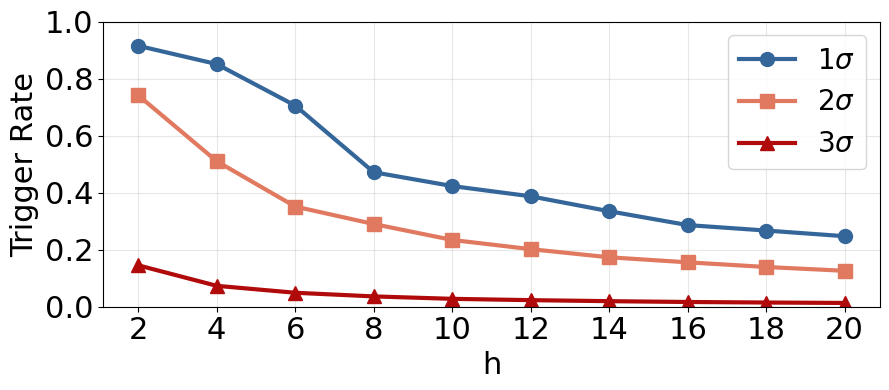

In [79]:
import matplotlib.pyplot as plt

# --- Style config ---
FIG_SIZE = (9, 4)
FONT_LABEL = 22
FONT_TICK = 22
FONT_LEGEND = 20
FONT_TITLE = 22

COLORS = {
    "1sigma": "#34669A",
    "2sigma": "#E0795F",
    "3sigma": "#B00A0B",
}

LABEL_MAP = {
    "1sigma": r"$1\sigma$",
    "2sigma": r"$2\sigma$",
    "3sigma": r"$3\sigma$",
}

# NEW: marker styles
MARKERS = {
    "1sigma": "o",   # circle
    "2sigma": "s",   # square
    "3sigma": "^",   # triangle
}

# --- Plot ---
plt.figure(figsize=FIG_SIZE)

for nu_name in sorted(res_df["nu_name"].unique()):
    sub = res_df[res_df["nu_name"] == nu_name]
    plt.plot(
        sub["h"],
        sub["trigger_rate"],
        marker=MARKERS.get(nu_name, "o"),
        linewidth=3,
        markersize=10,
        color=COLORS.get(nu_name, None),
        label=LABEL_MAP[nu_name]
    )

# --- Labels ---
plt.xlabel("h", fontsize=FONT_LABEL)
plt.ylabel("Trigger Rate", fontsize=FONT_LABEL)

# --- Ticks ---
plt.xticks(fontsize=FONT_TICK)
plt.xticks(h_list)
plt.yticks(fontsize=FONT_TICK)

# --- Legend ---
plt.legend(fontsize=FONT_LEGEND)

# --- Grid ---
plt.grid(alpha=0.3)

plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("../data/figs/rq3_calibration_overview.pdf", bbox_inches="tight")
plt.show()

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_gt_with_reset(z, nu, h):
    G = 0.0
    triggers = []
    G_series = []
    increments = []

    for t in range(len(z)):
        inc = z[t] - nu
        G = max(0.0, G + inc)
        G_series.append(G)
        increments.append(inc)

        if G > h:
            triggers.append(t)
            G = 0.0

    return np.array(G_series), np.array(increments), triggers


def extract_config_trace(test_df, nu, h):
    z = test_df["z_evidence"].to_numpy(dtype=float)
    f1 = test_df["f1_score"].to_numpy(dtype=float) if "f1_score" in test_df.columns else None

    G_series, increments, triggers = simulate_gt_with_reset(z, nu, h)

    out = test_df.copy()
    out["G_t"] = G_series
    out["increment"] = increments
    out["is_trigger"] = 0
    if len(triggers) > 0:
        out.loc[out.index[triggers], "is_trigger"] = 1

    if f1 is not None:
        out["f1_score"] = f1

    return out, triggers

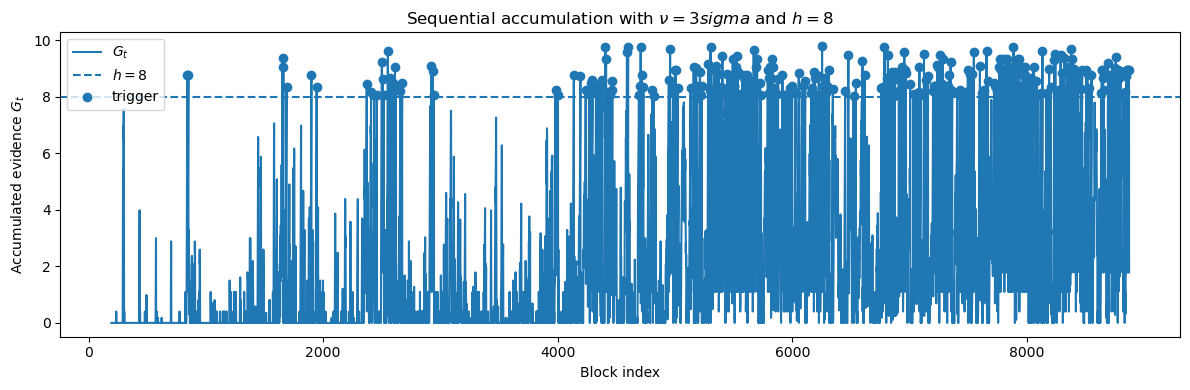

In [50]:
# selected operating point
nu_name = "3sigma"
h = 8

nu_value = nu_dict[nu_name]
trace_df, triggers = extract_config_trace(test_df, nu_value, h)

plt.figure(figsize=(12, 4))
plt.plot(trace_df["block_index"], trace_df["G_t"], label=r"$G_t$")
plt.axhline(h, linestyle="--", label=fr"$h={h}$")

if len(triggers) > 0:
    trig_x = trace_df.iloc[triggers]["block_index"]
    trig_y = trace_df.iloc[triggers]["G_t"]
    plt.scatter(trig_x, trig_y, label="trigger")

plt.xlabel("Block index")
plt.ylabel(r"Accumulated evidence $G_t$")
plt.title(fr"Sequential accumulation with $\nu={nu_name}$ and $h={h}$")
plt.legend()
plt.tight_layout()
plt.show()

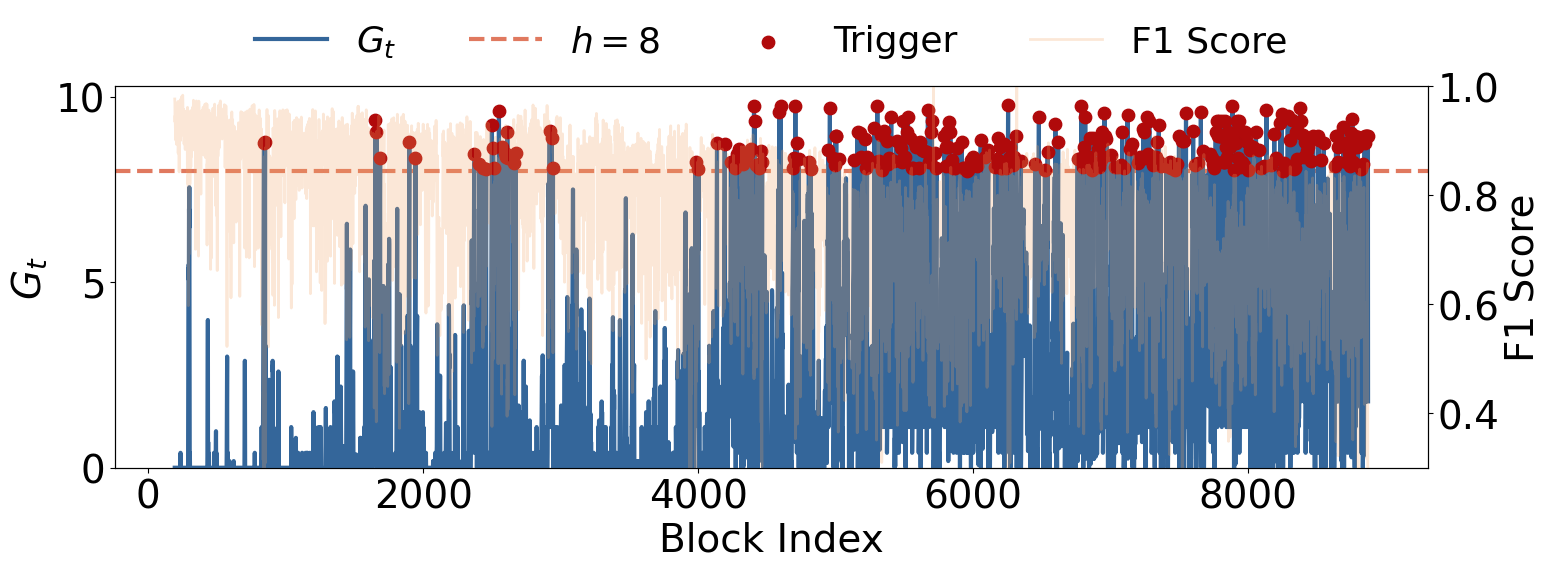

In [51]:
import matplotlib.pyplot as plt

# --- Style ---
FIG_SIZE = (16, 6)
FONT_LABEL = 28
FONT_TICK = 28
FONT_LEGEND = 26

COLORS = {
    "Gt": "#34669A",
    "threshold": "#E0795F",
    "trigger": "#B00A0B",
    "f1": "#f3a361",
}

fig, ax1 = plt.subplots(figsize=FIG_SIZE)

# --- G_t ---
ax1.plot(
    trace_df["block_index"],
    trace_df["G_t"],
    linewidth=3,
    color=COLORS["Gt"],
    label=r"$G_t$",
    zorder=3
)

# --- threshold ---
ax1.axhline(
    h,
    linestyle="--",
    linewidth=3,
    color=COLORS["threshold"],
    label=fr"$h={h}$",
    zorder=2
)

# --- triggers ---
if len(triggers) > 0:
    trig_x = trace_df.iloc[triggers]["block_index"]
    trig_y = trace_df.iloc[triggers]["G_t"]

    ax1.scatter(
        trig_x,
        trig_y,
        s=80,
        color=COLORS["trigger"],
        label="Trigger",
        zorder=4
    )

# --- axis ---
ax1.set_xlabel("Block Index", fontsize=FONT_LABEL)
ax1.set_ylabel(r"$G_t$", fontsize=FONT_LABEL)
ax1.tick_params(axis="both", labelsize=FONT_TICK)

# --- F1 (less overlap trick) ---
if "f1_score" in trace_df.columns:
    ax2 = ax1.twinx()

    ax2.plot(
        trace_df["block_index"],
        trace_df["f1_score"],
        linewidth=2,
        alpha=0.25,        # ↓ key change
        color=COLORS["f1"],
        label="F1 Score",
        zorder=1
    )

    ax2.set_ylabel("F1 Score", fontsize=FONT_LABEL)
    ax2.tick_params(axis="y", labelsize=FONT_TICK)

# --- legend on top ---
lines1, labels1 = ax1.get_legend_handles_labels()
if "f1_score" in trace_df.columns:
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        fontsize=FONT_LEGEND,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.25),
        ncol=4,
        frameon=False
    )
else:
    ax1.legend(
        fontsize=FONT_LEGEND,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.25),
        ncol=3,
        frameon=False
    )

# cleaner bounds
ax1.set_ylim(bottom=0)
ax2.set_ylim(0.3, 1.0)



plt.tight_layout()
plt.show()

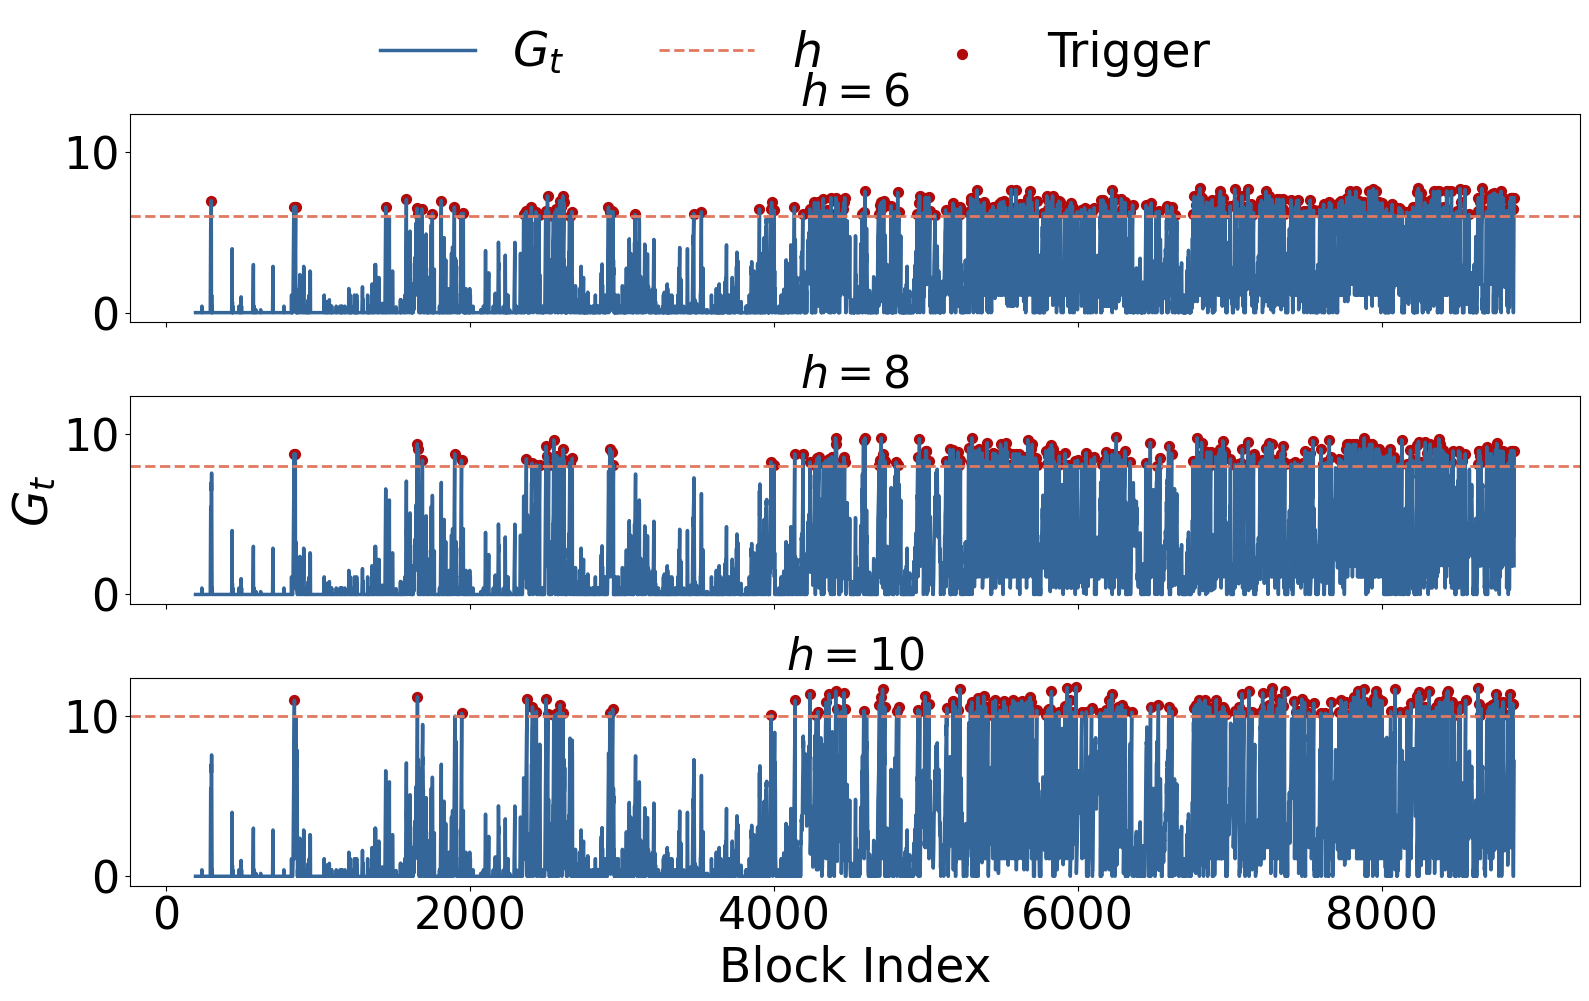

In [83]:
import matplotlib.pyplot as plt

# --- config ---
nu_name = "3sigma"
nu_value = nu_dict[nu_name]
compare_h = [6, 8, 10]

FIG_SIZE = (16, 10)
FONT_LABEL = 34
FONT_TICK =32
FONT_TITLE = 32

COLORS = {
    "Gt": "#34669A",
    "threshold": "#E0795F",
    "trigger": "#B00A0B",
}

# --- subplot ---
fig, axes = plt.subplots(len(compare_h), 1, figsize=FIG_SIZE, sharex=True, sharey=True)

for i, h in enumerate(compare_h):
    ax = axes[i]

    trace_df, triggers = extract_config_trace(test_df, nu_value, h)

    # G_t
    ax.plot(
        trace_df["block_index"],
        trace_df["G_t"],
        linewidth=2.5,
        color=COLORS["Gt"],
        label=r"$G_t$" if i == 0 else None   # only once
    )

    # threshold (label as generic "h")
    ax.axhline(
        h,
        linestyle="--",
        linewidth=2,
        color=COLORS["threshold"],
        label=r"$h$" if i == 0 else None
    )

    # triggers
    if len(triggers) > 0:
        trig_x = trace_df.iloc[triggers]["block_index"]
        trig_y = trace_df.iloc[triggers]["G_t"]

        ax.scatter(
            trig_x,
            trig_y,
            s=50,
            color=COLORS["trigger"],
            label="Trigger" if i == 0 else None
        )

    # y label only once
    if i == 1:   # center subplot
        ax.set_ylabel(r"$G_t$", fontsize=FONT_LABEL)

    # x label only at bottom
    if i == len(compare_h) - 1:
        ax.set_xlabel("Block Index", fontsize=FONT_LABEL)

    # ticks
    ax.tick_params(axis="both", labelsize=FONT_TICK)

    # subplot title
    ax.set_title(fr"$h={h}$", fontsize=FONT_TITLE)

# --- shared legend ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    fontsize=FONT_LABEL,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../data/figs/rq3_operational_behaviour.pdf", bbox_inches="tight")
plt.show()

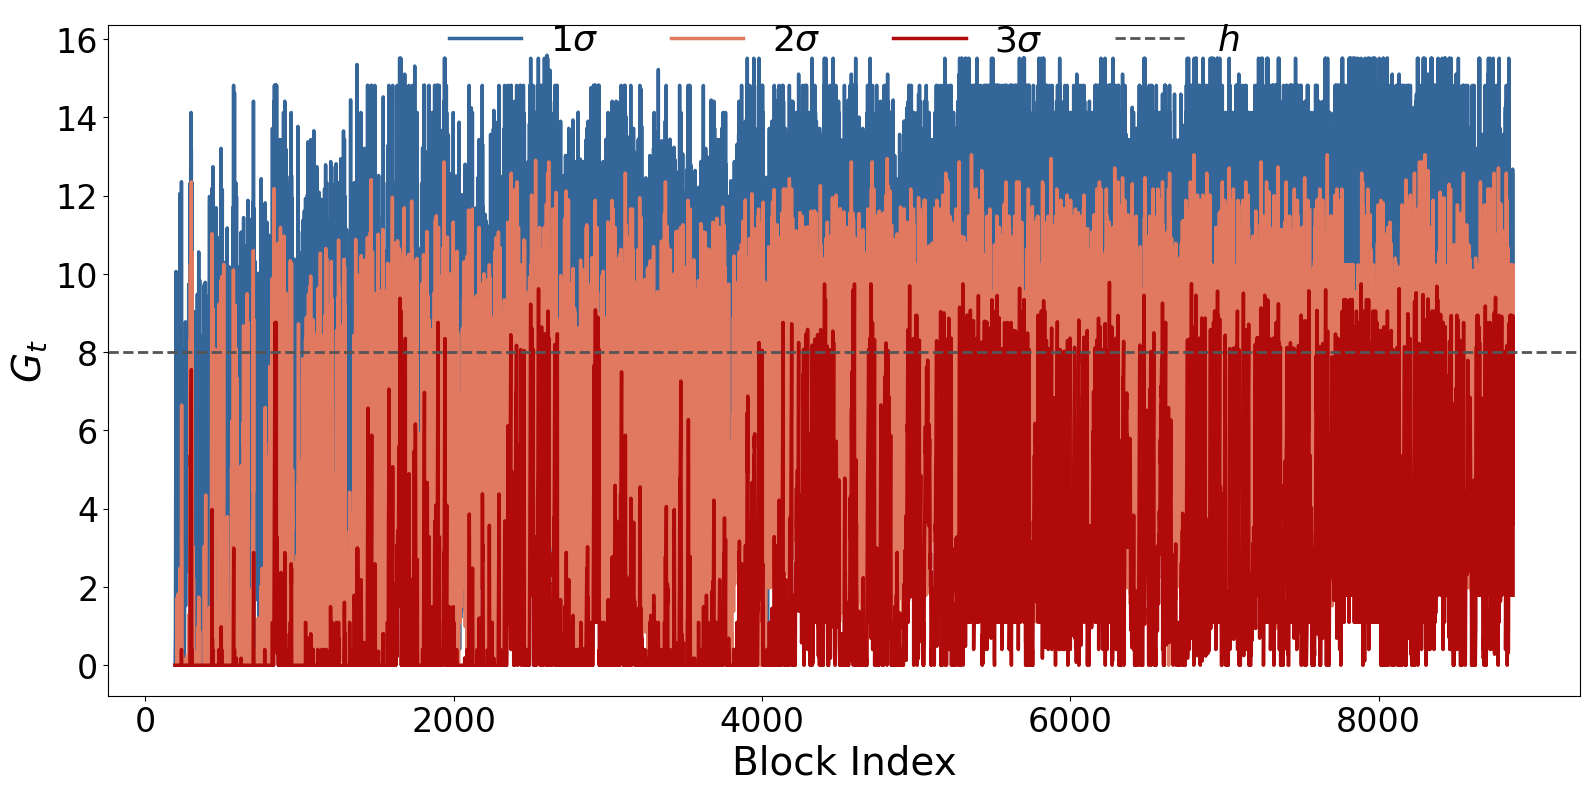

In [69]:
import matplotlib.pyplot as plt

# --- config ---
h = 8
compare_nu = ["1sigma", "2sigma", "3sigma"]

FIG_SIZE = (16, 8)
FONT_LABEL = 28
FONT_TICK = 24
FONT_LEGEND = 26

COLORS = {
    "1sigma": "#34669A",   # dark blue
    "2sigma": "#E0795F",   # orange
    "3sigma": "#B00A0B",   # red
}

# --- plot ---
plt.figure(figsize=FIG_SIZE)

for nu_name in compare_nu:
    nu_value = nu_dict[nu_name]

    trace_df, triggers = extract_config_trace(test_df, nu_value, h)

    # convert label to proper sigma
    if nu_name == "1sigma":
        label = r"$1\sigma$"
    elif nu_name == "2sigma":
        label = r"$2\sigma$"
    else:
        label = r"$3\sigma$"

    plt.plot(
        trace_df["block_index"],
        trace_df["G_t"],
        linewidth=2.5,
        color=COLORS[nu_name],
        label=label
    )

# threshold line (shared)
plt.axhline(
    h,
    linestyle="--",
    linewidth=2,
    color="#555555",
    label=r"$h$"
)

# --- labels ---
plt.xlabel("Block Index", fontsize=FONT_LABEL)
plt.ylabel(r"$G_t$", fontsize=FONT_LABEL)

# ticks
plt.xticks(fontsize=FONT_TICK)
plt.yticks(fontsize=FONT_TICK)

# legend
plt.legend(
    fontsize=FONT_LEGEND,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()

In [16]:
selected = res_df[(res_df["nu_name"] == "3sigma") & (res_df["h"] == 8)].iloc[0]

print("Selected configuration")
print(f"nu_name                : {selected['nu_name']}")
print(f"nu_value               : {selected['nu']:.4f}")
print(f"h                      : {selected['h']}")
print(f"trigger_rate           : {selected['trigger_rate']:.4f}")
print(f"n_triggers             : {int(selected['n_triggers'])}")
print(f"mean_interval          : {selected['mean_interval']:.4f}")
print(f"avg_f1_before_trigger  : {selected['avg_f1_before_trigger']:.4f}")

Selected configuration
nu_name                : 3sigma
nu_value               : 8.7369
h                      : 8
trigger_rate           : 0.0362
n_triggers             : 314
mean_interval          : 25.6518
avg_f1_before_trigger  : 0.6426
